[Spreadsheet](https://docs.google.com/spreadsheets/d/1-N7PAK-8XXx92BoGS7LWB4nOFhlJ_hMZ3YrYvJboEHc/edit?usp=sharing)

# Train a Model with FashionMNIST

* Beginner-level models (a couple of conv layers, basic training) → ~85–90%

* Well-tuned CNNs (more depth, dropout, batch norm, data augmentation) → 91–93%

* State-of-the-art on FashionMNIST → ~96–97%

Resetting the random seed inside every epoch

```
if random_seed is not None:
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.mps.manual_seed(random_seed)
```

* This is not good during training — it makes your data shuffling identical each epoch, which destroys the benefit of stochasticity and acts like you’re training on the same exact sequence over and over.

* That will accelerate overfitting because the model sees the exact same order and augmentations every epoch.

## **Outlines**

1. Load Fashion MNST Dataset
2. Use `torch.utils.data.DataLoader`
3. Create Test, Train and Eval Functions
4. Build a CNN Model with TinyVGG
5. Train, Test and Evaluate the Model
6. Go back to 4 and 5 to Customize the Model and beat 93% accuracy
7. Save and Load the best Model

## **0. Imports**

In [136]:
import torch
from torch import nn
from torch.utils.data.dataloader import DataLoader

import torchvision
from torchvision.datasets import FashionMNIST
from torchvision import transforms

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

torch.__version__, torchvision.__version__

('2.6.0+cu124', '0.21.0+cu124')

## **1. Device Agnostic**

In [137]:
!nvidia-smi

Fri Aug 15 21:48:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             29W /   70W |     354MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [138]:
if torch.cuda.is_available():
  DEVICE = "cuda"
elif torch.mps.is_available():
  DEVICE = "mps"
else:
  DEVICE="cpu"

DEVICE

'cuda'

## **2. Constants**

In [139]:
RANDOM_SEED = 42
BATCH_SIZE = 32

## **3. Load Data + Augmentation**

### 3.0. transforms.Compose

In [140]:
# ### Simple
# train_transforms = transforms.Compose([
#     transforms.ToTensor(),
#     # transforms.Normalize((0.5,), (0.5,))
# ])

# test_transforms = transforms.Compose([
#     transforms.ToTensor(),
#     # transforms.Normalize((0.5,), (0.5,))
# ])

In [141]:
# ### Mid
# train_transforms = transforms.Compose([
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(10),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
# ])

# test_transforms = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
# ])

In [142]:
### Heavy
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1,0.1)),  # small shifts
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

### 3.1. Load

In [143]:
train_data = FashionMNIST(root="./data", train=True, download=True, transform=train_transforms)
test_data = FashionMNIST(root="./data", train=False, download=True, transform=test_transforms)

In [144]:
classes_name = train_data.classes
print(classes_name)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [145]:
print(f"Data shape: {train_data[0][0].shape}")
print(f"Data label index: {train_data[0][1]}")
print(f"Data label name: {classes_name[train_data[0][1]]}")

Data shape: torch.Size([1, 28, 28])
Data label index: 9
Data label name: Ankle boot


In [146]:
len(train_data), len(test_data)

(60000, 10000)

## **4. Visualize Data**

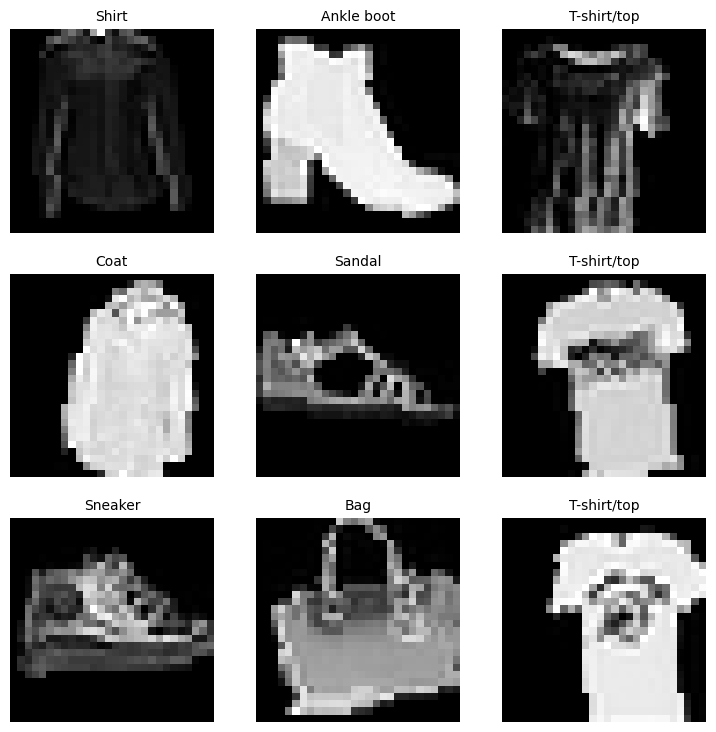

In [147]:
# Plot random samples
NUM_SAMPLES = 9
indexes = np.random.randint(low=0, high=len(train_data), size=(NUM_SAMPLES, ))

ncols = 3
nrows = (NUM_SAMPLES // ncols) + 1 if NUM_SAMPLES % 3 != 0 else NUM_SAMPLES // ncols

plt.figure(figsize=(9, 3 * nrows))

for i, idx in enumerate(indexes):
  sample = train_data[idx][0].cpu().numpy()
  label_idx = train_data[idx][1]

  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Get the label (in text form, e.g. "T-shirt")
  label = classes_name[label_idx]

  # Plot title
  plt.title(label, fontsize=10)

  plt.axis(False);

## **5. Prepare Dataloader**

In [148]:
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [149]:
print(f"Length of train dataloader: {len(train_dataloader)} batches of {train_dataloader.batch_size} (drop last batch is {train_dataloader.drop_last})")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {test_dataloader.batch_size} (drop last batch is {train_dataloader.drop_last})")

Length of train dataloader: 1875 batches of 32 (drop last batch is False)
Length of test dataloader: 313 batches of 32 (drop last batch is False)


## **6. Train, Test and Eval Functions**

### 6.0. Train

Resetting the random seed inside every epoch

* This is not good during training — it makes your data shuffling identical each epoch, which destroys the benefit of stochasticity and acts like you’re training on the same exact sequence over and over.

* That will accelerate overfitting because the model sees the exact same order and augmentations every epoch

In [150]:
def train_step(model: torch.nn.Module,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               dataloader: torch.utils.data.DataLoader,
               device: torch.device = "cpu"
               ):
  # model.to(device)
  model.train()

  total_loss = 0.0
  total_correct_predictions = 0
  total_samples = 0

  for batch, (data, target) in enumerate(dataloader):
    data, target = data.to(device), target.to(device)

    # Forward pass
    y_logits = model(data)

    # Calculate the Loss
    loss = loss_fn(y_logits, target)
    total_loss += (loss.item() * target.size(0))

    # Count correct predictions
    total_correct_predictions += (torch.argmax(y_logits, dim=1) == target).sum().item()
    total_samples += target.size(0)

    # Zero Grad
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Apply Grad
    optimizer.step()

  avg_loss = total_loss / total_samples
  accuracy = total_correct_predictions / total_samples * 100

  print(f"Train loss: {avg_loss:.5f} | Train accuracy: {accuracy:.2f}%")

  # return (avg_loss, accuracy)

### 6.1. Test

In [151]:
def test_step(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              device: torch.device = "cpu"
              ):

  # model.to(device)
  model.eval()

  total_loss = 0.0
  total_correct_predictions = 0
  total_samples = 0

  with torch.inference_mode():
    for batch, (data, target) in enumerate(dataloader):
      data, target = data.to(device), target.to(device)

      # Forward pass
      y_logits = model(data)

      # Calculate the Loss
      loss = loss_fn(y_logits, target)
      total_loss += (loss.item() * target.size(0))

      # Count correct predictions
      total_correct_predictions += (torch.argmax(y_logits, dim=1) == target).sum().item()
      total_samples += target.size(0)

  avg_loss = total_loss / total_samples
  accuracy = total_correct_predictions / total_samples * 100

  print(f"Test loss: {avg_loss:.5f} | Test accuracy: {accuracy:.2f}%")

  # return (avg_loss, accuracy)

### 6.2. Eval

In [152]:
def eval_model(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               device: torch.device = "cpu") -> tuple[np.ndarray, torch.Tensor, torch.Tensor]:
    """
    Return probability, prediction, and target of all samples as 1D tensors.
    """
    model.to(device)
    model.eval()

    y_probs = []
    y_preds = []
    targets = []

    with torch.inference_mode():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)

            # Forward pass
            y_logits = model(data)

            # Softmax probabilities and predictions
            probs = torch.softmax(y_logits, dim=1).max(dim=1).values
            preds = torch.argmax(y_logits, dim=1)

            y_probs.append(probs)
            y_preds.append(preds)
            targets.append(target)

    # Convert to proper types
    y_prob_np = torch.cat(y_probs).cpu().numpy()
    y_pred_tensor = torch.cat(y_preds).cpu()
    target_tensor = torch.cat(targets).cpu()

    return y_prob_np, y_pred_tensor, target_tensor

## **7. Model 0**

### 7.0. Build the Model

In [97]:
class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape: int,
                output_shape: int,
                hidden_units: int,
                fc_units: int,
                non_linear: bool=False
                ):
      """
      Model architecture copying TinyVGG from:
      https://poloclub.github.io/cnn-explainer/
      """

      super().__init__()

      self.input_shape = input_shape
      self.output_shape = output_shape
      self.hidden_units = hidden_units

      self.conv_block_0 = nn.Sequential(
          nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2,
          stride=2) # default stride value is same as kernel_size
      )

      self.conv_block_1 = nn.Sequential(
          nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
          nn.ReLU(), nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
          nn.ReLU(), nn.MaxPool2d(2)
      )


      if not non_linear:
          self.classifier = nn.Sequential(
              nn.Flatten(),
              nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
            )
      else:
          self.classifier = nn.Sequential(
              nn.Flatten(),
              nn.Linear(hidden_units * 7 * 7, fc_units), # intermediate FC
              nn.ReLU(True),
              nn.Dropout(0.5),
              nn.Linear(fc_units, output_shape)
            )

  def forward(self, x: torch.tensor) -> torch.tensor:
      x = self.conv_block_0(x)
      x = self.conv_block_1(x)
      x = self.classifier(x)

      return x

### 7.1. Train the Model

In [107]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

model_0 = FashionMNISTModelV0(1, len(classes_name), hidden_units=64, fc_units=128, non_linear=True).to(DEVICE)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [108]:
epochs = 10

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

for epoch in range(epochs):
  print(f"epoch: {epoch}\n\n{'-' * (7 + len(str(epoch)))}")
  start_time = time.time()

  train_step(model=model_0,
             loss_fn=loss_fn,
             optimizer=optimizer,
             dataloader=train_dataloader,
             device=DEVICE)

  test_step(model=model_0,
            loss_fn=loss_fn,
            dataloader=test_dataloader,
            device=DEVICE)

  print(f"Epoch time: {time.time() - start_time:.2f}s\n")

epoch: 0

--------
Train loss: 0.67059 | Train accuracy: 75.22%
Test loss: 0.36180 | Test accuracy: 86.73%
Epoch time: 16.44s

epoch: 1

--------
Train loss: 0.36858 | Train accuracy: 86.78%
Test loss: 0.29589 | Test accuracy: 88.84%
Epoch time: 16.32s

epoch: 2

--------
Train loss: 0.30359 | Train accuracy: 89.13%
Test loss: 0.26137 | Test accuracy: 90.53%
Epoch time: 16.96s

epoch: 3

--------
Train loss: 0.26884 | Train accuracy: 90.36%
Test loss: 0.24710 | Test accuracy: 91.10%
Epoch time: 16.31s

epoch: 4

--------
Train loss: 0.24150 | Train accuracy: 91.39%
Test loss: 0.24221 | Test accuracy: 91.18%
Epoch time: 15.37s

epoch: 5

--------
Train loss: 0.22313 | Train accuracy: 92.02%
Test loss: 0.23043 | Test accuracy: 91.80%
Epoch time: 17.18s

epoch: 6

--------
Train loss: 0.20569 | Train accuracy: 92.61%
Test loss: 0.21635 | Test accuracy: 92.24%
Epoch time: 15.92s

epoch: 7

--------
Train loss: 0.19379 | Train accuracy: 92.83%
Test loss: 0.21712 | Test accuracy: 91.91%
Epoc

### 7.2. Evaluate the Model

In [109]:
probs, preds, targets = eval_model(model=model_0, dataloader=test_dataloader, device=DEVICE)

In [110]:
print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy()))

              precision    recall  f1-score   support

           0       0.91      0.82      0.86      1000
           1       0.99      0.99      0.99      1000
           2       0.86      0.88      0.87      1000
           3       0.91      0.93      0.92      1000
           4       0.85      0.91      0.88      1000
           5       0.99      0.99      0.99      1000
           6       0.77      0.76      0.77      1000
           7       0.98      0.96      0.97      1000
           8       0.99      0.98      0.99      1000
           9       0.96      0.98      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



## **8. Model 1**

Add BatchNorm2d and Dropout

### 8.0. Build the Model

In [153]:
class FashionMNISTModelV2(nn.Module):
    def __init__(self, in_channels=1, num_classes=10, hidden_units=64):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.1)  # conv block dropout
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units*2, 3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_units*2, hidden_units*2, 3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units*2 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

### 8.1. Train the Model

In [154]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

model_1 = FashionMNISTModelV2().to(DEVICE)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model_1.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [157]:
epochs = 10

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

for epoch in range(epochs):
  print(f"epoch: {epoch}\n\n{'-' * (7 + len(str(epoch)))}")
  start_time = time.time()

  train_step(model=model_1,
             loss_fn=loss_fn,
             optimizer=optimizer,
             dataloader=train_dataloader,
             device=DEVICE)

  scheduler.step()

  test_step(model=model_1,
            loss_fn=loss_fn,
            dataloader=test_dataloader,
            device=DEVICE)

  print(f"Epoch time: {time.time() - start_time:.2f}s\n")

epoch: 0

--------
Train loss: 0.21634 | Train accuracy: 92.31%
Test loss: 0.18934 | Test accuracy: 93.36%
Epoch time: 35.54s

epoch: 1

--------
Train loss: 0.21246 | Train accuracy: 92.52%
Test loss: 0.19195 | Test accuracy: 93.36%
Epoch time: 34.94s

epoch: 2

--------
Train loss: 0.20715 | Train accuracy: 92.76%
Test loss: 0.19420 | Test accuracy: 93.54%
Epoch time: 36.58s

epoch: 3

--------
Train loss: 0.20347 | Train accuracy: 92.70%
Test loss: 0.19453 | Test accuracy: 93.58%
Epoch time: 35.24s

epoch: 4

--------
Train loss: 0.20345 | Train accuracy: 92.80%
Test loss: 0.19107 | Test accuracy: 93.49%
Epoch time: 34.15s

epoch: 5

--------
Train loss: 0.19254 | Train accuracy: 93.18%
Test loss: 0.18696 | Test accuracy: 93.69%
Epoch time: 37.08s

epoch: 6

--------
Train loss: 0.18914 | Train accuracy: 93.35%
Test loss: 0.19248 | Test accuracy: 93.62%
Epoch time: 35.76s

epoch: 7

--------
Train loss: 0.18150 | Train accuracy: 93.55%
Test loss: 0.18676 | Test accuracy: 93.84%
Epoc

### 8.2. Evaluate the Model

In [158]:
probs, preds, targets = eval_model(model=model_1, dataloader=test_dataloader, device=DEVICE)

In [159]:
print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy()))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1000
           1       0.99      0.99      0.99      1000
           2       0.92      0.91      0.91      1000
           3       0.93      0.94      0.94      1000
           4       0.89      0.94      0.91      1000
           5       0.99      0.98      0.98      1000
           6       0.81      0.81      0.81      1000
           7       0.97      0.97      0.97      1000
           8       0.99      1.00      0.99      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000

